**Autor:** PEDRO HENRIQUE BENICIO DE OLIVEIRA — **RGM:** 33602697

# Entrega 3 — Chunking de Manifestações Longas
As 5 manifestações mais longas são divididas com `RecursiveCharacterTextSplitter` (LangChain) em
diferentes configurações `(chunk_size, chunk_overlap)`. Avaliamos a coesão entre chunks consecutivos e
a proximidade dos chunks de uma mesma manifestação no espaço 2D.

In [1]:
import os, warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import ouvidoria_utils as u

df = u.carregar_manifestacoes()
textos = df["texto"].tolist()
idx = {i: k for k, i in enumerate(df["id"])}   # id -> posição na matriz
print(f"{len(df)} manifestações | categorias: {df.categoria_oficial.value_counts().to_dict()}")
df.head()

40 manifestações | categorias: {'meio ambiente': 9, 'infraestrutura': 8, 'saúde': 8, 'educação': 8, 'segurança': 7}


,id,data,categoria_oficial,texto
0,M001,2025-03-03,infraestrutura,O poste de iluminação da Rua das Flores está a...
1,M002,2025-03-05,saúde,Fui à UPA com febre alta e esperei mais de cin...
2,M003,2025-03-06,infraestrutura,"Existe um buraco enorme na Av. Brasil, na altu..."
3,M004,2025-03-08,segurança,Assaltos frequentes na parada de ônibus da Rua...
4,M005,2025-03-10,educação,Escrevo para relatar a situação da escola muni...


In [2]:
NOME = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = u.carregar_modelo(NOME)

longas = df.assign(n=df.texto.str.len()).nlargest(5, "n")
print(longas[["id", "categoria_oficial", "n"]].to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5522.44it/s]

  id categoria_oficial   n
M005          educação 682
M014             saúde 664
M027         segurança 661
M038     meio ambiente 628
M020    infraestrutura 620


## 1. Configurações testadas

In [3]:
CONFIGS = {
    "A: 200 / 0":   (200, 0),     # pequeno, sem overlap
    "B: 200 / 50":  (200, 50),    # pequeno, overlap menor que uma frase (sem efeito prático)
    "C: 400 / 0":   (400, 0),     # grande, sem overlap
    "D: 400 / 150": (400, 150),   # grande, overlap de ~1 frase
}

chunks = []   # todos os chunks de todas as configs
for cfg, (size, ov) in CONFIGS.items():
    for _, r in longas.iterrows():
        for k, c in enumerate(u.dividir_chunks(r.texto, size, ov, "Recursive")):
            chunks.append(dict(config=cfg, id=r["id"], chunk=k, texto=c, tam=len(c)))
ch = pd.DataFrame(chunks)
ch["emb_idx"] = range(len(ch))
E = u.codificar(modelo, ch.texto.tolist(), NOME)
ch.groupby("config").agg(n_chunks=("chunk", "size"), tam_medio=("tam", "mean")).round(1)

,n_chunks,tam_medio
config,,
A: 200 / 0,25,129.4
B: 200 / 50,25,129.4
C: 400 / 0,11,295.4
D: 400 / 150,14,299.8


## 2. Exemplo: manifestação M020 nas configurações A e D

In [4]:
for cfg in ["A: 200 / 0", "D: 400 / 150"]:
    print(f"\n########## {cfg}")
    for _, r in ch[(ch.config == cfg) & (ch.id == "M020")].iterrows():
        print(f"[{r.chunk}] ({r.tam} chars) {r.texto!r}")


########## A: 200 / 0
[0] (73 chars) 'Venho reclamar do abandono da Rua Sete de Setembro, no bairro Bela Vista.'
[1] (133 chars) 'O asfalto está cheio de crateras que se enchem de água quando chove, e os moradores já perderam a conta de rodas e pneus danificados.'
[2] (127 chars) 'As bocas de lobo estão entupidas de lixo e terra, e a cada temporal a rua vira um rio, com água entrando nas casas mais baixas.'
[3] (127 chars) 'Três postes estão sem lâmpada, deixando o trecho da esquina até a praça totalmente às escuras, e por isso aumentaram os furtos.'
[4] (156 chars) 'Também não há sinalização de trânsito: a placa de pare foi derrubada por um caminhão e nunca foi recolocada. Aguardamos uma vistoria da Secretaria de Obras.'

########## D: 400 / 150
[0] (335 chars) 'Venho reclamar do abandono da Rua Sete de Setembro, no bairro Bela Vista. O asfalto está cheio de crateras que se enchem de água quando chove, e os moradores já perderam a conta de rodas e pneus danificados. As bocas de lobo 

## 3. Overlap e coesão entre chunks consecutivos
Medimos o cosseno médio entre chunks **consecutivos** da mesma manifestação (maior = transição mais coesa) e o
cosseno médio entre chunks **não vizinhos** (linha de base).

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
linhas = []
for cfg in CONFIGS:
    viz, nviz = [], []
    for mid in longas.id:
        sub = ch[(ch.config == cfg) & (ch.id == mid)]
        S = cosine_similarity(E[sub.emb_idx.values])
        n = len(sub)
        viz += [S[i, i + 1] for i in range(n - 1)]
        nviz += [S[i, j] for i in range(n) for j in range(i + 2, n)]
    linhas.append(dict(config=cfg, sim_consecutivos=np.mean(viz), sim_nao_vizinhos=np.mean(nviz), diferença=np.mean(viz) - np.mean(nviz)))
coesao = pd.DataFrame(linhas).set_index("config").round(3)
coesao

,sim_consecutivos,sim_nao_vizinhos,diferença
config,,,
A: 200 / 0,0.355,0.326,0.029
B: 200 / 50,0.355,0.326,0.029
C: 400 / 0,0.514,0.382,0.132
D: 400 / 150,0.655,0.500,0.156


In [6]:
# Quantos chunks terminam/começam no meio de uma frase? (proxy de "sentido preservado")
def corta_frase(t):
    return (not t.rstrip().endswith((".", "!", "?"))) or t[0].islower()
ch["corte_no_meio"] = ch.texto.map(corta_frase)
ch.groupby("config").corte_no_meio.mean().mul(100).round(1).rename("% chunks com início/fim no meio de frase")

config
A: 200 / 0      0.0
B: 200 / 50     0.0
C: 400 / 0      0.0
D: 400 / 150    0.0
Name: % chunks com início/fim no meio de frase, dtype: float64

## 4. Espaço 2D (PCA e t-SNE) — chunks da mesma manifestação ficam próximos?

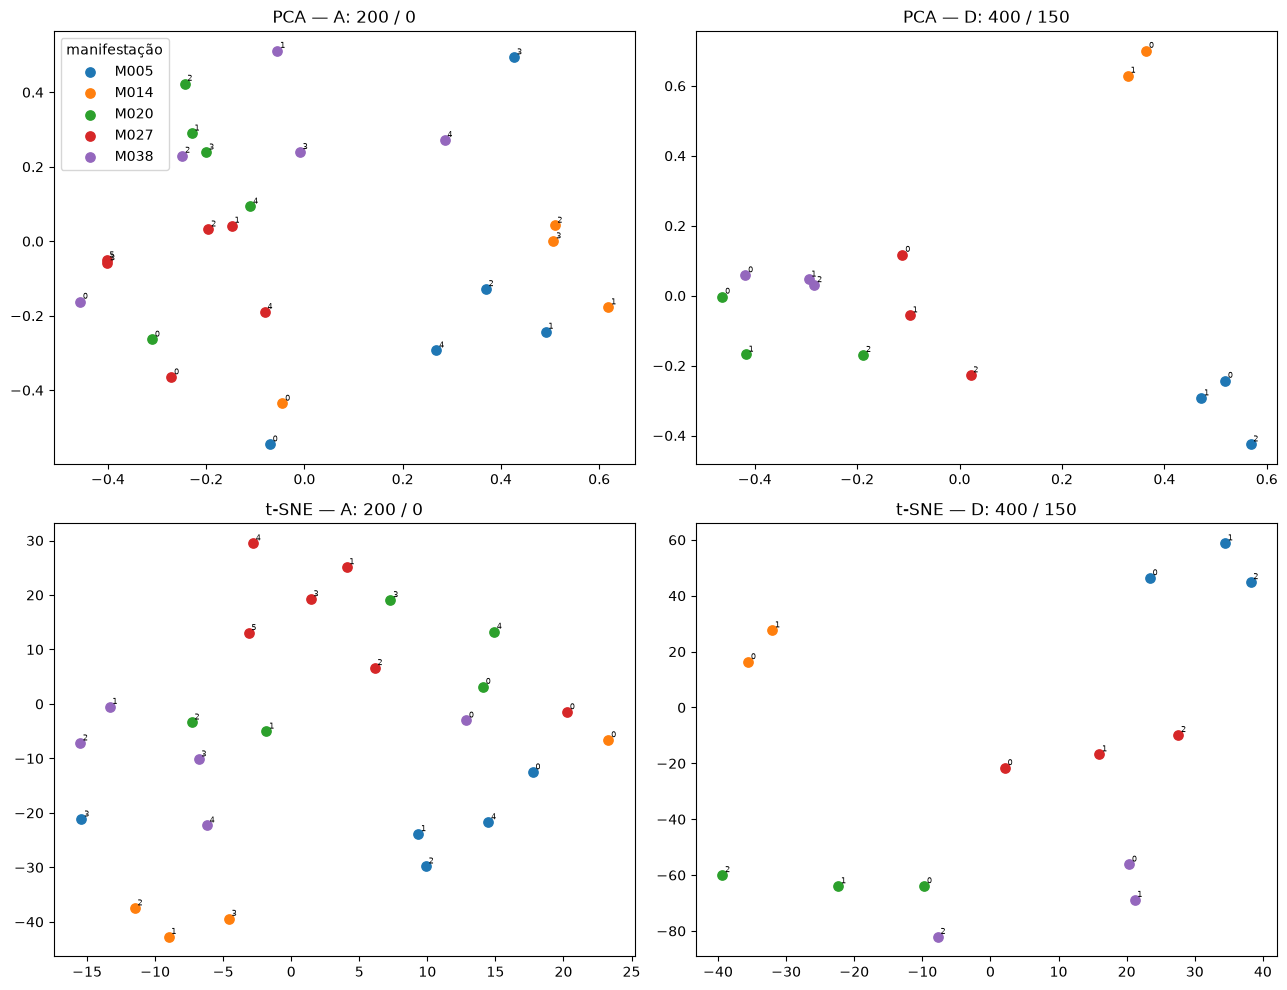

A: 200 / 0      0.045
B: 200 / 50     0.045
C: 400 / 0      0.097
D: 400 / 150    0.187
Name: silhouette (rótulo = manifestação de origem), dtype: float64

In [7]:
from sklearn.metrics import silhouette_score
def plotar(cfg, metodo, ax):
    sub = ch[ch.config == cfg]
    xy = u.reduzir_2d(E[sub.emb_idx.values], metodo)
    for mid, g in sub.groupby("id"):
        pos = [list(sub.index).index(i) for i in g.index]
        ax.scatter(xy[pos, 0], xy[pos, 1], label=mid, s=45)
        for k, p in zip(g.chunk, pos):
            ax.annotate(str(k), xy[p], fontsize=6, xytext=(2, 2), textcoords="offset points")
    ax.set_title(f"{metodo} — {cfg}")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (cfg, metodo) in zip(axes.ravel(), [("A: 200 / 0", "PCA"), ("D: 400 / 150", "PCA"), ("A: 200 / 0", "t-SNE"), ("D: 400 / 150", "t-SNE")]):
    plotar(cfg, metodo, ax)
axes[0, 0].legend(title="manifestação"); plt.tight_layout(); plt.show()

# Métrica objetiva: silhouette usando a manifestação de origem como rótulo (no espaço original)
sil = {cfg: silhouette_score(E[g.emb_idx.values], g.id) for cfg, g in ch.groupby("config")}
pd.Series(sil, name="silhouette (rótulo = manifestação de origem)").round(3)

In [8]:
# Dentro-vs-fora: vizinho mais próximo de cada chunk pertence à mesma manifestação?
linhas = []
for cfg, g in ch.groupby("config"):
    S = cosine_similarity(E[g.emb_idx.values]); np.fill_diagonal(S, -1)
    viz = S.argmax(axis=1)
    linhas.append(dict(config=cfg, acerto_vizinho_mais_proximo=(g.id.values[viz] == g.id.values).mean()))
pd.DataFrame(linhas).set_index("config").round(3)

,acerto_vizinho_mais_proximo
config,
A: 200 / 0,0.520
B: 200 / 50,0.520
C: 400 / 0,0.818
D: 400 / 150,0.929


## 5. Conclusões

**Efeito do overlap na coesão.** A similaridade média entre chunks consecutivos subiu de 0,51 (400/0) para
0,65 (400/150), enquanto a dos não vizinhos foi de 0,38 para 0,50: o overlap repete a frase de fronteira nos dois chunks,
e por isso os vizinhos "herdam" contexto comum. O ganho é real, mas parte dele é *repetição literal*, não coesão
temática pura — daí acompanhar também a diferença consecutivos − não vizinhos (0,13 → 0,16).
Observação importante: no `RecursiveCharacterTextSplitter` o overlap só existe quando as unidades de corte (aqui, frases de
~120–130 caracteres) cabem dentro do overlap **e** do chunk. Por isso as configs 200/0 e 200/50 são idênticas: com
overlap de 50 caracteres nenhuma frase inteira é repetida, e com chunk_size de 200 não cabem duas frases. Para o overlap agir,
`chunk_size` precisa ser ≥ ~3× o tamanho de uma frase e `chunk_overlap` ≈ 1 frase.

**Melhor configuração: 400/150.** (1) Preserva o sentido das denúncias: com chunks de 200 caracteres cada frase vira um chunk isolado
(ex.: "Três postes estão sem lâmpada…" sem saber que se trata da Rua Sete de Setembro); com 400/150 a frase de fronteira
aparece nos dois chunks e a queixa das bocas de lobo entupidas continua ligada a "a rua vira um rio" e ao alagamento.
(2) É a que mais recupera a origem do chunk: o vizinho mais próximo de um chunk pertence à mesma manifestação em 93% dos casos
(52% para 200/0, 82% para 400/0) e o silhouette (rótulo = manifestação) é o maior (0,19). (3) O custo é ~27% mais chunks
(14 × 11) e algum conteúdo duplicado no índice. Em todas as configs 0% dos chunks começam/terminam no meio de frase,
graças à hierarquia de separadores (`\n\n`, `\n`, `. `, `; `, `, `, ` `).

**Espaço 2D.** Os chunks de uma mesma manifestação tendem a ficar próximos, mas não formam clusters compactos: os textos
são *multi-assunto* (M020 mistura buracos, alagamento, iluminação e sinalização; M027 mistura assaltos, casa abandonada e
velocidade), então chunks de temas iguais em manifestações diferentes (ex.: iluminação em M020 e M027) se aproximam entre
si. PCA (2 componentes) preserva pouca variância de embeddings de 384 dimensões e mostra a separação apenas de forma grosseira;
o t-SNE separa melhor localmente, mas suas distâncias globais não são interpretáveis. Por isso a métrica quantitativa
(vizinho mais próximo e silhouette) é mais confiável do que a inspeção visual.
